In [1]:
import shap
from utils.data_loader import load_folktables_income_data, load_gbs_gesis, load_breast_cancer_data
import seaborn as sns
import pandas as pd
import numpy as np
seed = 5
np.random.seed(seed)
from utils.sampling import  sample_with_test_set
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from utils.metrics import calculate_feature_importance, train_pu_classifier
from sklearn.model_selection import KFold
from utils.metrics import compute_feature_weights_with_temperature, compute_test_metrics_fw_mrs

In [2]:
df, columns, target = load_breast_cancer_data()
df[columns] = StandardScaler().fit_transform(df[columns])
# N = df[df["label"] == 1]
# R = df[df["label"] == 0]
N, R, T = sample_with_test_set(
           "less_positive_class",
           df,
           target,
           train_fraction=0.5,
           bias_fraction=0.1,
           test_fraction=0.1,
           columns=columns,
       )

In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=5)
feature_importance_list = []
train = pd.concat([N, R])
clf = train_pu_classifier(train[columns], train.label)
abs_feature_importance, _, shap_values = calculate_feature_importance(
        test_N=N[columns].values,
        clf=clf,
    )

ValueError: not enough values to unpack (expected 3, got 2)

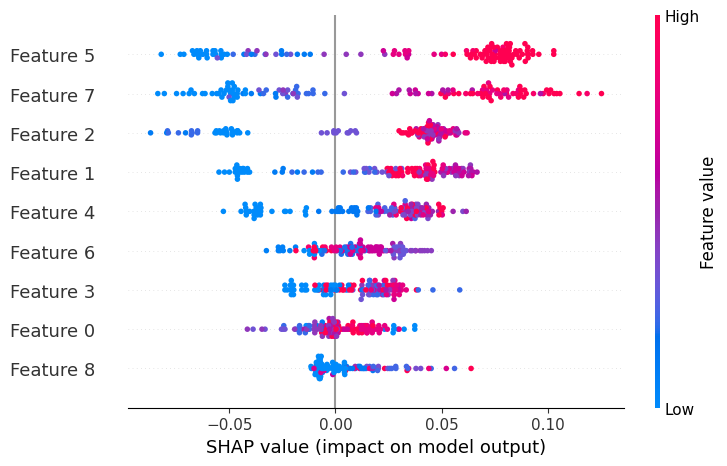

In [ ]:
shap.plots.beeswarm(shap_values[:, :, 1], )

In [ ]:
all_fw = np.mean(np.abs(shap_values.values[:, :, 1]), axis=0)
undersampled_shap = shap_values
# undersampled_shap.values[:, :, 1][undersampled_shap.values[:, :, 1] > 0] = 0
undersampled_fw = np.abs(np.min(undersampled_shap.values[:, :, 1], axis=0))

<Axes: ylabel='None'>

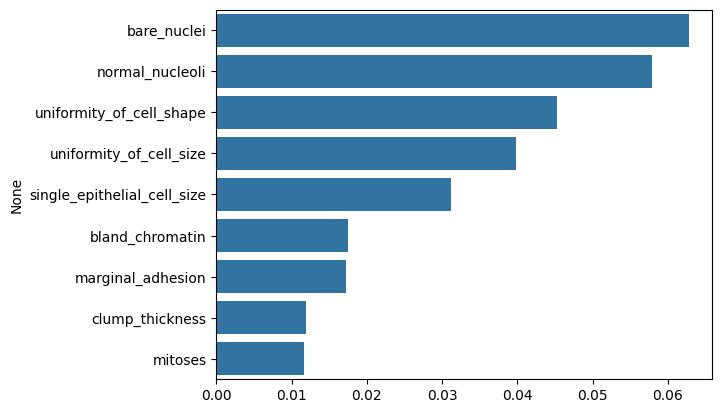

In [ ]:
sorted_indices = np.argsort(all_fw)
sns.barplot(x=all_fw[sorted_indices[:-10:-1]], y=columns[sorted_indices[:-10:-1]])

<Axes: ylabel='None'>

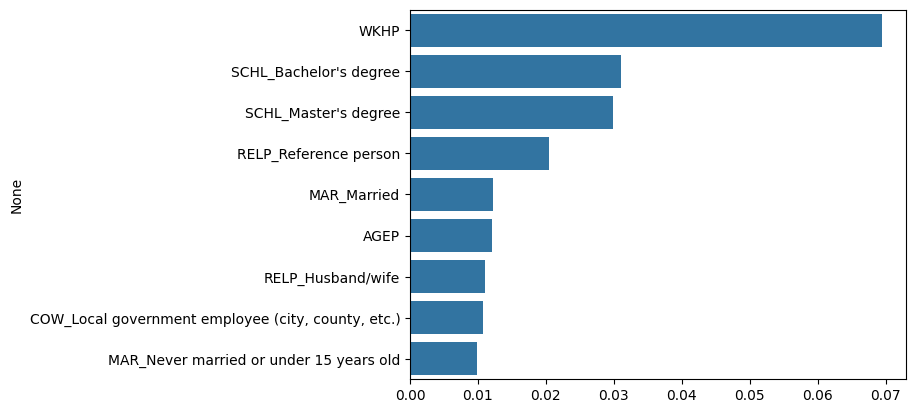

In [ ]:
sorted_indices = np.argsort(undersampled_fw)
sns.barplot(x=undersampled_fw[sorted_indices[:-10:-1]], y=columns[sorted_indices[:-10:-1]])

In [ ]:
feature_weights_list = []
budgets = [None, 0.1, 0.05, 0.01, 0.005, 0.001]
for budget in budgets:
    feature_weights = compute_feature_weights_with_temperature(budget, all_fw)
    feature_weights_list.append(feature_weights)

In [ ]:
for i, budget in enumerate(budgets):
    auroc = compute_test_metrics_fw_mrs(
        N,
        R,
        columns,
        random_state=seed,
        feature_weights=feature_weights_list[i],
        class_weight="balanced",
        max_features="sqrt",
        splitter="feature_weighted_best",
        n_splits_test=10,
        n_estimators=300,
        draw_with_feature_weights=True,
    )
    print(f"{budget}: {auroc}")

None: 0.6140267443171409
0.1: 0.6144210682694702
0.05: 0.6135702835440184
0.01: 0.6122479471713713
0.005: 0.6024756344039045
0.001: 0.5775822775593418


In [ ]:
feature_weights_list = []
budgets = [None, 0.1, 0.05, 0.01, 0.005, 0.001]
for budget in budgets:
    feature_weights = compute_feature_weights_with_temperature(budget, undersampled_fw)
    feature_weights_list.append(feature_weights)
for i, budget in enumerate(budgets):
    auroc = compute_test_metrics_fw_mrs(
        N,
        R,
        columns,
        random_state=seed,
        feature_weights=feature_weights_list[i],
        class_weight="balanced",
        max_features="sqrt",
        splitter="feature_weighted_best",
        n_splits_test=10,
        n_estimators=300,
        draw_with_feature_weights=True,
    )
    print(f"{budget}: {auroc}")

None: 0.6140267443171409
0.1: 0.6143917643756722
0.05: 0.6088509914175791
0.01: 0.5944968632120895
0.005: 0.5968895946955284
0.001: 0.5757629376353481
